In [1]:
import mne
import numpy as np
import pandas as pd
from scipy.signal import welch
import matplotlib.pyplot as plt
from scipy.signal import butter, welch, sosfiltfilt, buttord, sosfreqz
import os
import urllib.request

### PUNTO 1
---
# Paso 1 del flujo: inspección inicial

In [2]:
DATA_PATH = '.'
BASE_URL  = 'https://s3.amazonaws.com/openneuro.org/ds004362'

# Runs de interés únicamente
RUNS_BASELINE = [1, 2]
RUNS_TAREA1   = [3, 7, 11]   # movimiento real mano izq/der
RUNS_TAREA2   = [4, 8, 12]   # imaginación mano izq/der
RUNS_INTERES  = RUNS_BASELINE + RUNS_TAREA1 + RUNS_TAREA2  # [1,2,3,4,7,8,11,12]

SUJETOS = list(range(1, 110))  # 109 sujetos

total   = len(SUJETOS) * len(RUNS_INTERES)
cuenta  = 0

for sujeto in SUJETOS:
    sub = f'sub-{sujeto:03d}'
    carpeta = os.path.join(DATA_PATH, sub, 'eeg')
    os.makedirs(carpeta, exist_ok=True)

    for run in RUNS_INTERES:
        nombre     = f'{sub}_task-motion_run-{run}_eeg.set'
        ruta_local = os.path.join(carpeta, nombre)
        url        = f'{BASE_URL}/{sub}/eeg/{nombre}'
        cuenta    += 1

        # Si ya existe y pesa más de 1KB (no es puntero), saltar
        if os.path.exists(ruta_local) and os.path.getsize(ruta_local) > 1000:
            print(f'[{cuenta}/{total}] Ya existe: {nombre}')
            continue

        try:
            print(f'[{cuenta}/{total}] Descargando: {nombre}...')
            urllib.request.urlretrieve(url, ruta_local)
            print(f'  OK')
        except Exception as e:
            print(f'  ERROR: {nombre} → {e}')

print('\n¡Descarga completa!')

[1/872] Ya existe: sub-001_task-motion_run-1_eeg.set
[2/872] Ya existe: sub-001_task-motion_run-2_eeg.set
[3/872] Ya existe: sub-001_task-motion_run-3_eeg.set
[4/872] Ya existe: sub-001_task-motion_run-7_eeg.set
[5/872] Ya existe: sub-001_task-motion_run-11_eeg.set
[6/872] Ya existe: sub-001_task-motion_run-4_eeg.set
[7/872] Ya existe: sub-001_task-motion_run-8_eeg.set
[8/872] Ya existe: sub-001_task-motion_run-12_eeg.set
[9/872] Ya existe: sub-002_task-motion_run-1_eeg.set
[10/872] Ya existe: sub-002_task-motion_run-2_eeg.set
[11/872] Ya existe: sub-002_task-motion_run-3_eeg.set
[12/872] Ya existe: sub-002_task-motion_run-7_eeg.set
[13/872] Ya existe: sub-002_task-motion_run-11_eeg.set
[14/872] Ya existe: sub-002_task-motion_run-4_eeg.set
[15/872] Ya existe: sub-002_task-motion_run-8_eeg.set
[16/872] Ya existe: sub-002_task-motion_run-12_eeg.set
[17/872] Ya existe: sub-003_task-motion_run-1_eeg.set
[18/872] Ya existe: sub-003_task-motion_run-2_eeg.set
[19/872] Ya existe: sub-003_task-

In [3]:
DATA_PATH = r'C:\Users\valen\Downloads\Sujetos_Proyecto_1-20260430T175821Z-3-001\Sujetos_Proyecto_1'

ruta_ejemplo = f'{DATA_PATH}/sub-001/eeg/sub-001_task-motion_run-4_eeg.set'
raw_ejemplo  = mne.io.read_raw_eeglab(ruta_ejemplo, preload=True)

print(raw_ejemplo)
print(raw_ejemplo.info)
print(raw_ejemplo.ch_names)
print(raw_ejemplo.annotations)

DATA_PATH = r'C:\Users\valen\Downloads\Sujetos_Proyecto_1-20260430T175821Z-3-001\Sujetos_Proyecto_1'

ruta_ejemplo = f'{DATA_PATH}/sub-004/eeg/sub-004_task-motion_run-4_eeg.set'
raw_ejemplo  = mne.io.read_raw_eeglab(ruta_ejemplo, preload=True)

print(raw_ejemplo)
print(raw_ejemplo.info)
print(raw_ejemplo.ch_names)
print(raw_ejemplo.annotations)

<RawEEGLAB | sub-001_task-motion_run-4_eeg.set, 64 x 20000 (125.0 s), ~9.8 MiB, data loaded>
<Info | 8 non-empty values
 bads: []
 ch_names: Fc5, Fc3, Fc1, Fcz, Fc2, Fc4, Fc6, C5, C3, C1, Cz, C2, C4, C6, ...
 chs: 64 EEG
 custom_ref_applied: False
 dig: 67 items (3 Cardinal, 64 EEG)
 highpass: 0.0 Hz
 lowpass: 80.0 Hz
 meas_date: unspecified
 nchan: 64
 projs: []
 sfreq: 160.0 Hz
>
['Fc5', 'Fc3', 'Fc1', 'Fcz', 'Fc2', 'Fc4', 'Fc6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'Cp5', 'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4', 'Cp6', 'Fp1', 'Fpz', 'Fp2', 'Af7', 'Af3', 'Afz', 'Af4', 'Af8', 'F7', 'F5', 'F3', 'F1', 'Fz', 'F2', 'F4', 'F6', 'F8', 'Ft7', 'Ft8', 'T7', 'T8', 'T9', 'T10', 'Tp7', 'Tp8', 'P7', 'P5', 'P3', 'P1', 'Pz', 'P2', 'P4', 'P6', 'P8', 'Po7', 'Po3', 'Poz', 'Po4', 'Po8', 'O1', 'Oz', 'O2', 'Iz']
<Annotations | 30 segments: TASK2T0 (15), TASK2T1 (8), TASK2T2 (7)>
<RawEEGLAB | sub-004_task-motion_run-4_eeg.set, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>
<Info | 8 non-empty values
 bads: []


De la estructura del .set observamos que la señal tiene todo el rango de 0-80 Hz sin un procesamiento de pasa altas, por lo que se encuentran frecuencias pequeñas incluyendo la línea base. El equipo aplicó un filtro antialiasing a 80 Hz antes de digitalizar la señal. Dado que la frecuencia de muestreo es 160 Hz, el teorema de Nyquist establece que solo pueden representarse correctamente frecuencias de hasta fs/2 = 80 Hz. Este filtro evita que componentes de mayor frecuencia presentes en la señal analógica se traduzcan en aliasing dentro del rango digital.

Se encuentran 64 canales, de los cuales se eligen solamente los canales de interés propuestos en el análisis anterior.

Se observan diferencia entre número de anotaciones y tiempos de la señal entre ambos sujetos, por lo que se analizarán los 109 sujetos para observar si hay casos atípicos de la toma de la señal.

In [4]:
SUJETOS_MUESTRA = list(range(1, 110))  # Todos los sujetos

for sujeto in SUJETOS_MUESTRA:
    sub = f'sub-{sujeto:03d}'
    print(f'\n{"="*60}')
    print(f'SUJETO: {sub}')
    print(f'{"="*60}')
    
    for run in RUNS_INTERES:
        ruta = f'{DATA_PATH}/{sub}/eeg/{sub}_task-motion_run-{run}_eeg.set'
        
        try:
            raw  = mne.io.read_raw_eeglab(ruta, preload=False, verbose=False)
            tipos = {}
            for ann in raw.annotations:
                t = ann['description']
                tipos[t] = tipos.get(t, 0) + 1
            duracion = raw.times[-1]
            total_ann = sum(tipos.values())
            print(f'  Run {run:2d} | {duracion:6.1f}s | Total anotaciones: {total_ann:2d} | {tipos}')
        except Exception as e:
            print(f'  Run {run:2d} | ERROR: {e}')


SUJETO: sub-001
  Run  1 |   61.0s | Total anotaciones:  1 | {'BASE1T0': 1}
  Run  2 |   61.0s | Total anotaciones:  1 | {'BASE2T0': 1}
  Run  3 |  125.0s | Total anotaciones: 30 | {'TASK1T0': 15, 'TASK1T2': 7, 'TASK1T1': 8}
  Run  7 |  125.0s | Total anotaciones: 30 | {'TASK1T0': 15, 'TASK1T1': 8, 'TASK1T2': 7}
  Run 11 |  125.0s | Total anotaciones: 30 | {'TASK1T0': 15, 'TASK1T1': 7, 'TASK1T2': 8}
  Run  4 |  125.0s | Total anotaciones: 30 | {'TASK2T0': 15, 'TASK2T2': 7, 'TASK2T1': 8}
  Run  8 |  125.0s | Total anotaciones: 30 | {'TASK2T0': 15, 'TASK2T1': 8, 'TASK2T2': 7}
  Run 12 |  125.0s | Total anotaciones: 30 | {'TASK2T0': 15, 'TASK2T2': 8, 'TASK2T1': 7}

SUJETO: sub-002
  Run  1 |   61.0s | Total anotaciones:  1 | {'BASE1T0': 1}
  Run  2 |   61.0s | Total anotaciones:  1 | {'BASE2T0': 1}
  Run  3 |  123.0s | Total anotaciones: 30 | {'TASK1T0': 15, 'TASK1T1': 8, 'TASK1T2': 7}
  Run  7 |  123.0s | Total anotaciones: 30 | {'TASK1T0': 15, 'TASK1T2': 8, 'TASK1T1': 7}
  Run 11 |  12

Se observa que el tiempo de la señal varía entre 123-125s por run de tarea, 
consistente con los runs de dos minutos descritos en el dataset. Es una variacón poco significativa, por lo que la duración de cada segmento se estimó calculando la diferencia entre tiempos de inicios consecutivos de anotaciones (T0,T1,T2), obteniendo aproximadamente **4.1s por segmento** 
y **4.2s por período de reposo (T0)**. Por esto se define `TMIN=0, TMAX=4.0s`. 
Los runs de baseline (1 y 2) no tienen trials individuales sino una sola 
anotación T0 que cubre el minuto completo, por lo que se toma la señal 
completa como referencia de reposo sin hacer epoching.

Se identificaron tres sujetos atípicos:

<table style="border-collapse: collapse; width: 100%; font-family: Arial, sans-serif; font-size: 14px; color: black;">
  <caption style="font-weight: bold; text-align: left; margin-bottom: 6px; font-size: 14px; color: black;">
    Tabla 1. Evaluación de sujetos y decisiones de inclusión.
  </caption>
  <thead>
    <tr style="background-color: #f2f2f2; color: black;">
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Sujeto</th>
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Problema</th>
      <th style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">Decisión</th>
    </tr>
  </thead>
  <tbody>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">sub-092</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: justify;">38 eventos por run</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;">Se incluye, estructura internamente consistente</td>
    </tr>
    <tr style="background-color: #ffffff;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">sub-100</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: justify;">24 eventos por run para T1 y T2</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;">Se incluye, estructura internamente consistente</td>
    </tr>
    <tr style="background-color: #f9f9f9;">
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: center;">sub-089</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px; text-align: justify;">Run 3 con 44 anotaciones y 181s; baseline con aeventos extra</td>
      <td style="border: 1px solid #ccc; padding: 8px 12px;">Se excluyen run 3 y runs 1-2; demás runs se conservan</td>
    </tr>
  </tbody>
</table>

In [5]:
# Se definen las constantes y la función para cargar la señal 
FS   = 160.0
TMIN = 0.0
TMAX = 4.0
CANALES_INTERES = [
    'Fz',
    'Fc3', 'Fc1', 'Fc4',
    'C5',  'C3',  'Cz',  'C4',
    'Cp3', 'Cp1', 'Cpz', 'Cp2', 'Cp4',
    'P1',  'P2',  'Poz'
]
def load_raw(sujeto_id, run_id, data_path=DATA_PATH):
    """
    Carga un archivo .set de EEGLAB con MNE.
    Retorna mne.io.Raw con datos en memoria, o None si no existe.
    """
    ruta = os.path.join(
        data_path, sujeto_id, 'eeg',
        f'{sujeto_id}_task-motion_run-{run_id}_eeg.set'
    )
    if not os.path.exists(ruta):
        print(f'  [AVISO] Archivo no encontrado: {ruta}')
        return None
    return mne.io.read_raw_eeglab(ruta, preload=True, verbose=False)

# Paso 2 del flujo: Inspección pre filtrado


In [ ]:
BANDAS_REFERENCIA = {
    'Delta\n(0.5–4)' : (0.5,  4.0),
    'Theta\n(4–8)'   : (4.0,  8.0),
    'Mu\n(8–12)'     : (8.0, 12.0),
    'Beta\n(13–30)'  : (13.0, 30.0),
    'Gamma\n(30–40)' : (30.0, 40.0),
}
COLORES_BANDAS = ['#d4e6f1', '#d5f5e3', '#fdebd0', '#f9ebea', '#e8daef']

def inspect_raw(raw, sujeto_id, run_id, canales=CANALES_INTERES, fs=FS):
    """
    Inspección PRE-filtrado: viewer interactivo MNE + PSD por Welch.
    Retorna (data_raw, presentes).
    """
    presentes = [c for c in canales if c in raw.ch_names]
    raw.pick(presentes)
    data_raw = raw.get_data()    # (n_ch, n_muestras)
    n_ch     = len(presentes)

    # 1. Viewer interactivo — dominio temporal completo navegable
    # Requiere %matplotlib qt activo antes de llamar esta función
    raw.plot(duration=10, n_channels=n_ch, scalings='auto', block=False,
             title=f'PRE-filtrado | {sujeto_id} run-{run_id}')

    # 2. PSD por Welch, vectorizado sobre axis=1 (todos los canales a la vez)
    # nperseg = 2 s → resolución frecuencial = 0.5 Hz
    # noverlap = 50% → reduce varianza de la estimación espectral
    %matplotlib inline
    nperseg    = int(2 * fs)
    freqs, psd = welch(data_raw, fs=fs, nperseg=nperseg,
                       noverlap=nperseg // 2, axis=1)   # (n_ch, n_freqs)

    fig, ax = plt.subplots(figsize=(14, 5))
    fig.suptitle(f'PSD PRE-filtrado | {sujeto_id} run-{run_id} '
                 f'({n_ch} canales · fs={int(fs)} Hz)', fontweight='bold')

    for (nombre, (fl, fh)), color in zip(BANDAS_REFERENCIA.items(), COLORES_BANDAS):
        ax.axvspan(fl, fh, color=color, alpha=0.5, label=nombre)

    # Trazos individuales: psd.T tiene shape (n_freqs, n_ch) → una línea por canal
    ax.semilogy(freqs, psd.T, lw=0.4, color='steelblue', alpha=0.4)
    ax.semilogy(freqs, psd.mean(axis=0), lw=1.8, color='navy',
                label='Promedio canales')
    ax.axvline(60, color='red', lw=1.2, ls=':', label='60 Hz (red eléctrica)')
    ax.set(xlabel='Frecuencia (Hz)', ylabel='PSD (V²/Hz)', xlim=[0, 80])
    ax.legend(fontsize=7, ncol=2)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

    return data_raw, presentes


sub-001 run-3, Movimiento real


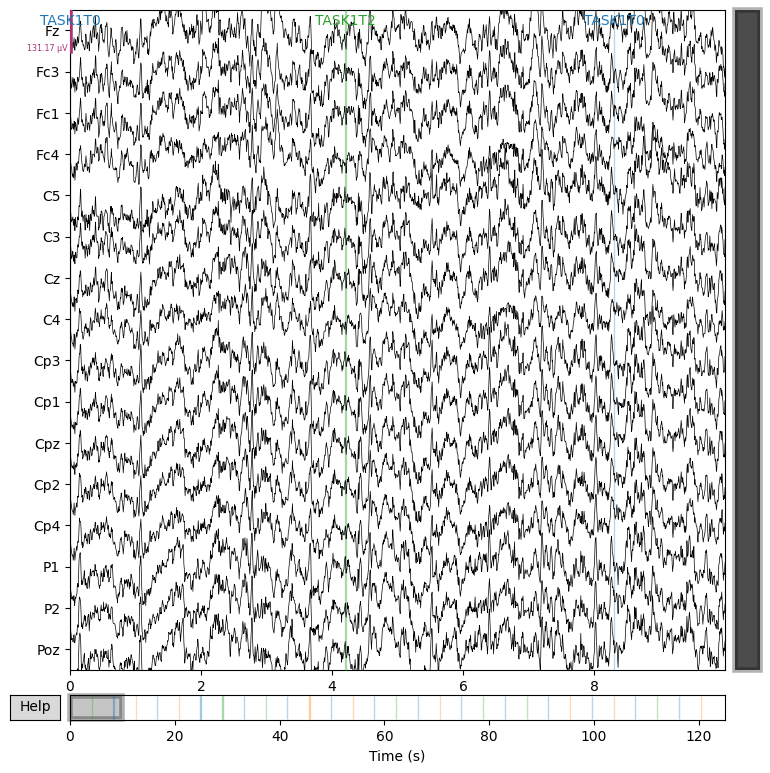

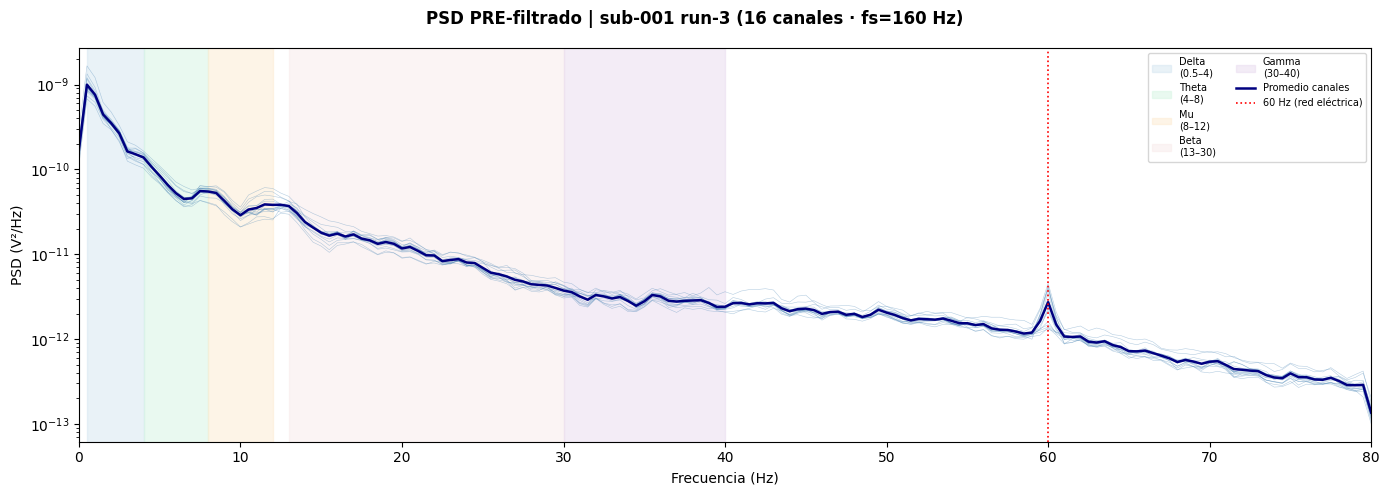

Channels marked as bad:
none
  Shape señal cruda: (16, 20000)

sub-001 run-4, Imaginación motora


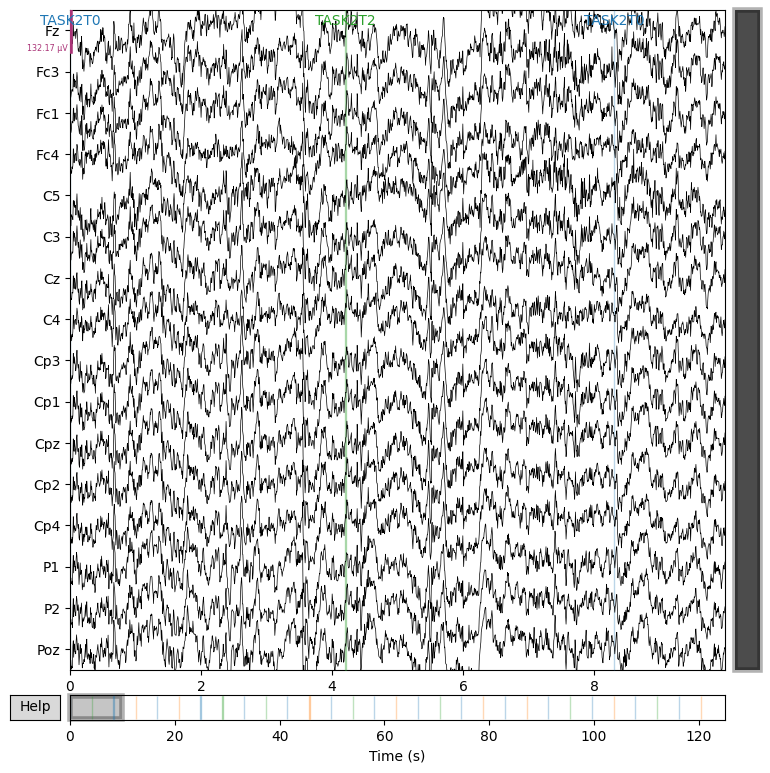

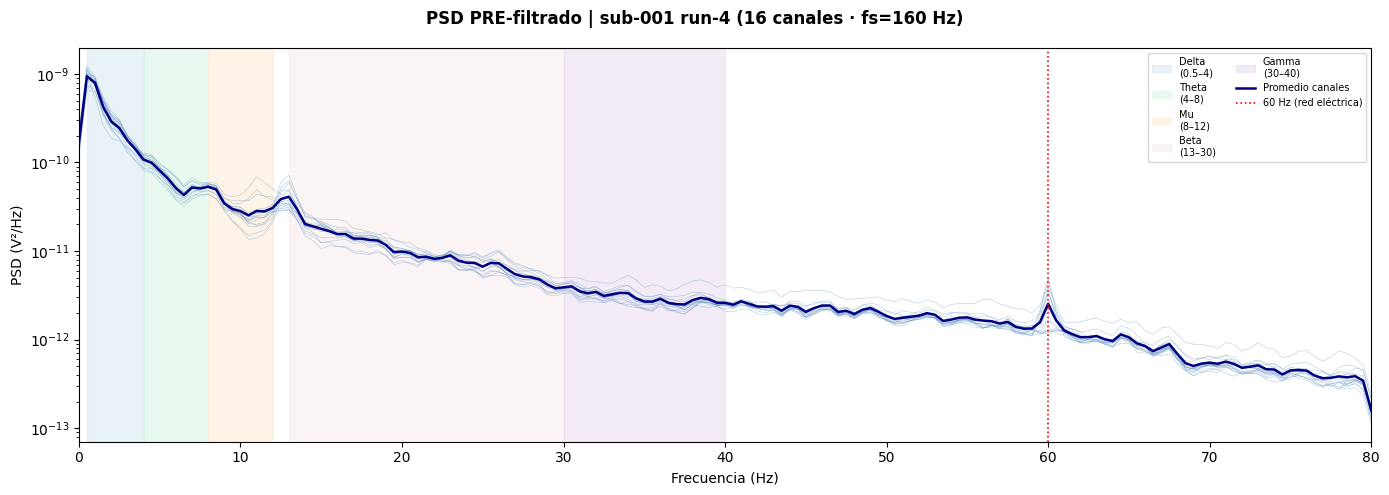

  Shape señal cruda: (16, 20000)


In [15]:
# Ejemplo señal curda 
%matplotlib qt
SUJ_REF     = 'sub-001'
RUNS_INSPEC = {3: 'Movimiento real', 4: 'Imaginación motora'}
for run_id, etiqueta in RUNS_INSPEC.items():
    print(f'\n{SUJ_REF} run-{run_id}, {etiqueta}')
    raw_ref = load_raw(SUJ_REF, run_id)
    if raw_ref is not None:
        data_raw, presentes = inspect_raw(raw_ref, SUJ_REF, run_id)
        print(f'  Shape señal cruda: {data_raw.shape}')

# ▶ COMMIT 2 — inspect_raw() implementada, inspección pre-filtrado verificada